In [1]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Tools, reports and sessions in the store agent

| | |
|-|-|
| Author(s) | [Matt Robinson](https://github.com/mr394729) |

> **This copy keeps the output of one complete run** (24 September 2026, in a test namespace), so you can read what each cell prints even if a cell fails for you. Your numbers and wording will differ where a model answers. To start clean, choose **Edit > Clear Outputs of All Cells** in JupyterLab, or run `jupyter nbconvert --clear-output --inplace <notebook>`.

## Overview

### Tools in ADK

A [function tool](https://google.github.io/adk-docs/tools/function-tools/) is a Python function that an agent can call. ADK reads the function's name, its parameters and its docstring, and sends them to the model as a function declaration. The model decides when to call the tool and with which arguments; your code runs the function and returns the result to the model.

### The store agent's tools

The store agent reads its data through tools. Each tool returns the same envelope: a `status`, the `rows`, and counts that say how many records matched. The model chooses the query, and the tool code adds the signed-in store and checks the person's role on every call, whatever the question says. When a result is too large for an answer, the tool delivers it as a report: the app shows the table and a CSV download, and the model only receives a summary. In this notebook you call the tools directly with your own credentials; the deployed agent calls the same functions through its MCP server, which you start in notebook 05.

<img width="60%" src="../docs/diagrams/query-report.png" alt="The model chooses a query, code enforces the store and role, and large results become a report" />

### Sessions and state

A [session](https://google.github.io/adk-docs/sessions/session/) holds one conversation: its events and a `state` dictionary. The store agent reads who is signed in from session state, never from the question, so a person cannot talk their way into another store.

### Objectives

In this tutorial, you will learn how the store agent's tools work and how a session carries identity and context between turns.

You will complete the following tasks:

- Look at the function declaration the model receives for a tool
- Call the agent's tools directly and read the results they return
- See the store and role boundary enforced inside a tool
- Combine several reads into one decision for a product
- Deliver a large result as a report and save it as CSV
- Run the agent in a session and see what the session keeps between turns

### Costs

This tutorial uses billable components of Google Cloud:

- Gemini on Vertex AI
- BigQuery

Learn about [Vertex AI pricing](https://cloud.google.com/vertex-ai/pricing) and [BigQuery pricing](https://cloud.google.com/bigquery/pricing), and use the [Pricing Calculator](https://cloud.google.com/products/calculator/) to generate a cost estimate based on your projected usage.

## Get started

### Set Google Cloud project information

This notebook runs against the store data you loaded in notebook 01, in your own namespace. Set your project ID and the namespace you chose during setup.

Learn more about [setting up a project and a development environment](https://cloud.google.com/vertex-ai/docs/start/cloud-environment).

In [2]:
import os
import sys
from pathlib import Path

PROJECT_ID = "[your-project-id]"  # @param {type: "string"}
WORKSHOP_NAMESPACE = "[your-namespace]"  # @param {type: "string"}

if PROJECT_ID == "[your-project-id]":
    PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "")
if WORKSHOP_NAMESPACE == "[your-namespace]":
    WORKSHOP_NAMESPACE = os.environ.get("WORKSHOP_NAMESPACE", "")
if not PROJECT_ID or not WORKSHOP_NAMESPACE:
    raise ValueError("Set PROJECT_ID and WORKSHOP_NAMESPACE above.")

os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
os.environ["WORKSHOP_NAMESPACE"] = WORKSHOP_NAMESPACE
os.environ["GOOGLE_CLOUD_LOCATION"] = "global"
os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "TRUE"
os.environ["STORE_OPS_ENV"] = "dev"

# The agent's code lives one folder up from this notebook
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

### Import libraries

In [3]:
import json
import logging
import warnings
from types import SimpleNamespace

# Keep the notebook output to the agent's own events: ADK marks experimental features with a
# UserWarning, and the Gen AI SDK logs a note whenever a response mixes text and tool calls.
warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("google_genai").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import pandas as pd
from google.adk.runners import InMemoryRunner
from google.adk.tools import FunctionTool
from google.genai import types

from agents.cymbal_store_ops.agent import create_app
from agents.cymbal_store_ops.tools.inventory_context import get_inventory_context
from agents.cymbal_store_ops.tools.inventory_summary import get_store_inventory_summary
from agents.cymbal_store_ops.tools.store_query import describe_store_data, query_store_data

## See what the model sees

The model never sees your Python code. It sees the declaration ADK builds from the function signature and docstring. Build the declaration for `query_store_data`, the agent's general query tool:

In [4]:
declaration = FunctionTool(query_store_data)._get_declaration()

print(declaration.description)
print()
print("Parameters:", list(declaration.parameters_json_schema["properties"]))

Read or aggregate operational records using a model-chosen query plan.

Resources: inventory, orders, tasks, traffic, loss, feedback, reviews, deliveries, roster.
describe_store_data supplies fields and data limitations. Filters are ANDed;
string values are converted using field types. Measures produce operation_field
aliases (count_records when field is empty). Grouping/aggregation happens in the
database across ALL matching records before pagination. No SQL or expressions
accepted. Store/role access is enforced independently of supplied filters.
Answer delivery returns a page of 1–100 records. Report delivery displays the
matching table in the app and returns only its metadata here; it always starts
at the first row and caps the table at 5,000 rows, independently of limit/offset.
The report's complete flag states whether every matching row was included.

Parameters: ['resource', 'fields', 'filters', 'group_by', 'measures', 'order_by', 'limit', 'offset', 'store_id', 'delivery']


The docstring is the tool's instructions. That is why the store agent's prompts do not tell the model which tool to use for which question: each tool describes what it can do, and the model plans from the question.

## Call a tool directly

A tool is a normal Python function, so you can call it yourself. In the agent, ADK passes a `ToolContext` that carries the session state. Here, a simple object with a `state` dictionary stands in for it. Sign in as Dana, the manager of store S-014:

In [5]:
dana = SimpleNamespace(
    state={
        "user:user_id": "U-M014",
        "user:store_id": "S-014",
        "user:role": "store_manager",
        "user:first_name": "Dana",
    }
)

### Read a resource's schema

`describe_store_data` returns the fields, types and allowed values of a resource. The model calls it before it writes a query, so it only asks in terms the tool understands:

In [6]:
schema = describe_store_data("inventory", tool_context=dana)
inventory = schema["rows"][0]

print(inventory["description"])
pd.Series(inventory["fields"], name="type").to_frame()

Recorded gross stock, not available-to-promise. Retail value uses selling price, not cost. All products, including healthy stock.


,type
product_id,text
product_name,text
brand,text
category,text
subcategory,text
price_usd,number
locked_case,boolean
is_fragrance_free,boolean
skin_types,text
key_ingredients,text


### Query with filters

Ask for haircare products in the inventory. The result holds one page of rows, plus `total_matching`, the number of records that match across the whole store:

In [7]:
result = query_store_data(
    "inventory",
    fields=["product_id", "product_name", "price_usd", "on_hand"],
    filters=[{"field": "category", "operator": "eq", "value": "haircare"}],
    limit=5,
    tool_context=dana,
)

print(f"{result['returned_count']} rows returned of {result['total_matching']} matching")
pd.DataFrame(result["rows"])

5 rows returned of 120 matching


,product_id,product_name,price_usd,on_hand
0,P-0181,Lift Shampoo,38.99,8
1,P-0182,Glow Conditioner,14.99,2
2,P-0183,Bloom Hair Mask,18.00,17
3,P-0184,Glow Leave-In,28.00,16
4,P-0185,Renew Styling Cream,28.00,10


### Totals across all matching records

Totals are computed in BigQuery over every matching record before paging, so they are never a sum of the page you happen to see. Ask for the count and the units on hand of products under $30 with at least five units:

In [8]:
FILTERS = [
    {"field": "price_usd", "operator": "lte", "value": "30"},
    {"field": "on_hand", "operator": "gte", "value": "5"},
]

totals = query_store_data(
    "inventory",
    filters=FILTERS,
    measures=[{"operation": "count"}, {"operation": "sum", "field": "on_hand"}],
    tool_context=dana,
)
totals["rows"]

[{'count_records': 250, 'sum_on_hand': 2964}]

250 products match across all categories. The tool counts them in BigQuery; it does not return 250 rows.

### The same tool, a different person

Priya is an associate at the same store. She can read her store's inventory. A request for another store is refused inside the tool before any data is read:

In [9]:
priya = SimpleNamespace(
    state={
        "user:user_id": "A-1004",
        "user:store_id": "S-014",
        "user:role": "associate",
        "user:first_name": "Priya",
    }
)

own_store = query_store_data("inventory", filters=FILTERS, limit=3, tool_context=priya)
other_store = query_store_data("inventory", store_id="S-015", limit=3, tool_context=priya)

print("Own store:    ", own_store["status"], f"{own_store.get('total_matching')} matching")
print("Another store:", other_store["status"], other_store.get("error_details"))

Own store:     SUCCESS 250 matching
Another store: ERROR This session can read only its signed-in store.


The store comes from the session state, so no wording in a question can change it.

### Summarize the whole store

Some questions need a summary rather than a query. `get_store_inventory_summary` returns fixed totals for the whole store, by category:

In [10]:
summary = get_store_inventory_summary(tool_context=dana)
pd.DataFrame(summary["rows"])

,category,inventory_row_count,sku_count,stocked_sku_count,on_hand_units,on_shelf_units,backroom_units,empty_shelf_sku_count,out_of_stock_sku_count,low_stock_sku_count
0,bath,80,80,77,725,510,215,1,3,8
1,fragrance,70,70,67,728,521,207,0,3,5
2,haircare,120,120,118,1240,863,377,2,2,9
3,makeup,150,150,148,1441,1009,432,3,2,6
4,skincare,180,180,176,1740,1216,524,4,4,15


The five categories add up to 5,874 units on hand, the same total you computed in notebook 01.

## Combine evidence for one product

A specialist rarely answers from one read. `get_inventory_context` reads stock, pickup reservations, locations, inbound deliveries and open tasks for one product at the same time, then returns a `decision` that separates reserved units from demand, and unknown evidence from zero.

Read the evidence for Lumière Hydra Cream (P-0101):

In [11]:
context = await get_inventory_context("P-0101", tool_context=dana)
evidence = context["rows"][0]

print(json.dumps(evidence["decision"], indent=2))

{
  "action": "pick_reserved_then_replenish",
  "evidence_gaps": [],
  "stock_observation_age_minutes": 15.0,
  "reservations_known": true,
  "reserved_units": 4,
  "observed_reserved_units": 4,
  "pending_order_count": 3,
  "pending_demand_units": 4,
  "unreserved_pending_units": 0,
  "available_to_promise_units": 3,
  "shelf_replenishment_units": 3,
  "physical_check_needed": false,
  "quantity_basis": "gross_saleable_including_reservations",
  "existing_open_task_count": 0,
  "inbound_delayed": true
}


Lumière Hydra Cream has 7 units. Three pending orders reserve 4 of them, which leaves 3 to promise and to move to the shelf. Inbound stock is delayed, and `evidence_gaps` is empty, so no read came back unknown.

The pickup orders behind the reservation. Three orders is not the same as the number of units they hold, and a good answer keeps the two apart:

In [12]:
orders = pd.DataFrame(evidence["demand"]["rows"])[["order_id", "qty", "promised_at", "status"]]
orders

,order_id,qty,promised_at,status
0,BO-000651,1,2026-10-03T09:30-05:00,pending
1,BO-000652,2,2026-10-03T09:45-05:00,pending
2,BO-000653,1,2026-10-03T10:00-05:00,pending


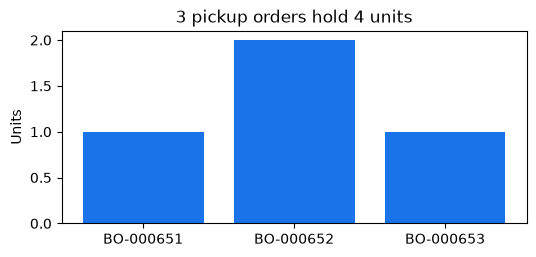

In [13]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.bar(orders["order_id"], orders["qty"], color="#1a73e8")
ax.set_ylabel("Units")
ax.set_title(f"{len(orders)} pickup orders hold {orders['qty'].sum()} units")
plt.show()

## Deliver a large result as a report

The model works best with a short answer, not five thousand rows. When the agent needs the full table, it asks for a report: here, the same query with `delivery="report"`; in the agent, the coordinator's `deliver_store_report` tool does the same. The tool puts the rows in session state for the app to show as a searchable table with a CSV download, and returns only the metadata to the model:

In [14]:
report = query_store_data(
    "inventory",
    fields=["product_id", "product_name", "category", "on_hand"],
    delivery="report",
    tool_context=dana,
)

report

{'status': 'SUCCESS',
 'rows': [],
 'resource': 'inventory',
 'store_id': 'S-014',
 'as_of': '2026-10-03T09:00:00-05:00',
 'report_id': 'b8aa6c93-b337-4105-a7bf-8908fb4515f7',
 'row_count': 600,
 'total_matching': 600,
 'complete': True,
 'display': 'report',
 'data_notes': 'Recorded gross stock, not available-to-promise. Retail value uses selling price, not cost. All products, including healthy stock.'}

The model receives no rows, only the counts: 600 rows, all of them included (`complete: True`).

The rows are in the session state under `ui:report`. Save them as CSV, the same file the app offers for download:

In [15]:
report_rows = pd.DataFrame(dana.state["ui:report"]["rows"])
report_rows.to_csv("inventory_report.csv", index=False)

print(f"Saved {len(report_rows)} rows to inventory_report.csv")
report_rows.head()

Saved 600 rows to inventory_report.csv


,product_id,product_name,category,on_hand
0,P-0001,Hydra Moisturizer,skincare,15
1,P-0002,Bright Cleanser,skincare,15
2,P-0003,Velvet Serum,skincare,3
3,P-0004,Lift Sunscreen,skincare,12
4,P-0005,Lift Toner,skincare,5


## Run the agent in a session

Now put a question to the agent itself. `create_app()` builds the same app that runs on Agent Runtime; `log_events=False` leaves out the plugin that prints every event to the log.

<img width="50%" src="../docs/diagrams/sessions.png" alt="A session holds the conversation's events and state" />

Create a runner and a session for Dana. The identity goes into the session state before the first message:

In [16]:
app = create_app(log_events=False)
runner = InMemoryRunner(app=app)

session = await runner.session_service.create_session(
    app_name=app.name,
    user_id="dana",
    state=dana.state | {},
)

Define a helper that sends one message and prints each tool call and the final answer:

In [17]:
async def ask(question: str) -> None:
    """Send one message in the session and print the tool calls and the final answer."""
    message = types.Content(role="user", parts=[types.Part(text=question)])
    async for event in runner.run_async(
        user_id=session.user_id, session_id=session.id, new_message=message
    ):
        for call in event.get_function_calls():
            print(f"[{event.author}] calls {call.name}({json.dumps(call.args)[:100]})")
        if event.is_final_response() and event.content and event.content.parts:
            text = "".join(part.text or "" for part in event.content.parts if not part.thought)
            if text:
                print(f"\n{text}")

Ask a question like the queries you wrote by hand. Compare the tools and filters the model chooses with yours. When many products match, the model may deliver a report instead of listing them:

In [18]:
await ask("Which haircare products under $30 do we have at least five of?")

[store_manager_agent] calls describe_store_data({"resource": "inventory"})


[store_manager_agent] calls query_store_data({"resource": "inventory", "limit": 25, "filters": [{"operator": "eq", "field": "category", "value": )


[store_manager_agent] calls deliver_store_report({"fields": ["product_id", "product_name", "price_usd", "on_hand", "on_shelf_qty", "backroom_qty"], ")



Inventory report ready: 53 of 53 matching records.


The model read the schema, queried a first page, then called `deliver_store_report` because 53 products matched. When that tool is the coordinator's only call, it ends the turn without another model call, so the answer is the one line about the report. The model's choices can differ from run to run. In the tablet app the table appears under the answer; here, read it from the session:

In [19]:
turn = await runner.session_service.get_session(
    app_name=app.name, user_id=session.user_id, session_id=session.id
)
report = turn.state.get("ui:report") or {}
print(f"{len(report.get('rows', []))} rows in the report")
pd.DataFrame(report.get("rows", [])).head(8)

53 rows in the report


,product_id,product_name,price_usd,on_hand,on_shelf_qty,backroom_qty
0,P-0268,Pure Leave-In,9.49,28,14,14
1,P-0272,Silk Conditioner,18.00,26,20,6
2,P-0287,Clear Styling Cream,12.50,23,19,4
3,P-0234,Bloom Dry Shampoo,12.00,22,0,22
4,P-0250,Bright Leave-In,24.50,22,18,4
5,P-0270,Clear Dry Shampoo,12.00,22,14,8
6,P-0222,Bright Dry Shampoo,28.99,21,16,5
7,P-0240,Bright Dry Shampoo,22.50,21,10,11


Ask a follow-up in the same session. The agent sees the earlier turn, so "those" refers to the products it just found:

In [20]:
await ask("Which of those has the most units on hand?")

[store_manager_agent] calls query_store_data({"limit": 5, "filters": [{"field": "category", "operator": "eq", "value": "haircare"}, {"field": "pr)


[store_manager_agent] calls query_store_data({"filters": [{"field": "product_id", "operator": "eq", "value": "P-0268"}], "resource": "inventory"})



Pure Leave-In (P-0268) has the highest stock among haircare products under $30, with 28 units on hand (14 on the shelf and 14 in the backroom).

The next highest are Silk Conditioner (P-0272) with 26 units on hand (20 shelf, 6 backroom) and Clear Styling Cream (P-0287) with 23 units (19 shelf, 4 backroom).


The follow-up runs new queries with the filters taken from the first turn. In this run the answer is Pure Leave-In (P-0268), 28 units. The wording differs from run to run; the product and the count should match.

### What the session keeps

Read the session back. It holds every event of both turns, and the state holds the signed-in identity. Keys that start with `temp:` last for one turn only and are not saved:

In [21]:
saved = await runner.session_service.get_session(
    app_name=app.name, user_id=session.user_id, session_id=session.id
)

print(f"{len(saved.events)} events in the session")
print("State keys:", sorted(key for key in saved.state if key.startswith("user:")))

19 events in the session
State keys: ['user:first_name', 'user:role', 'user:store_id', 'user:user_id']


Two turns produced 19 events: each message, tool call, tool result and answer is one event.

Try these example phrases in a new cell with `await ask(...)`:

```
Show me every skincare product as a report
What is the stock position for P-0233, and is any of it reserved?
Show me the inventory for store S-015
```

## Try the agent in a browser

The agent you just questioned in a session also runs in two browser apps on your machine, with nothing deployed. Both read the store data you loaded in notebook 01, in your namespace, with your own sign-in. Run them in a terminal from the repository root.

**The tablet app**, the same app the demo uses:

```bash
uv run python frontend/server.py --target local --port 8080
```

Open http://localhost:8080, choose the manager or the associate, and pick a starter question. **Activity** lists each tool and agent call as it happens, and **View trace** opens the spans of a turn. Locally there is no password.

**The ADK developer UI**, for looking inside each turn:

```bash
uv run adk web agents --port 8000
```

Open http://localhost:8000 and choose `cymbal_store_ops`. The agent answers a signed-in person, so start with "I'm U-M014, the store manager at Naperville." The **Events** tab shows every model and tool call.

Locally the agent reads BigQuery directly. The agent you deploy in notebook 05 reads the same data through your MCP server.

## Cleaning up

This notebook creates no cloud resources. The sessions lived in memory and end when you restart the kernel. Delete the CSV file you saved:

In [22]:
Path("inventory_report.csv").unlink(missing_ok=True)

## What's next

- [ADK function tools](https://google.github.io/adk-docs/tools/function-tools/)
- [ADK sessions and state](https://google.github.io/adk-docs/sessions/state/)
- [The store agent's tools](../agents/cymbal_store_ops/tools/): every docstring is what the model reads
- Next notebook: [Evaluate and observe the store agent](04_evaluate_and_observe.ipynb)